In [44]:
# Libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, root_mean_squared_error
import numpy as np
import scipy as scp
from sklearn.feature_selection import SelectFromModel
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, FunctionTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.neighbors import KNeighborsRegressor
from pandas.plotting import scatter_matrix
print("LIBRARIES IMPORTED")


LIBRARIES IMPORTED


In [45]:
data = pd.read_csv("https://raw.githubusercontent.com/semingrai/Hands-on-ML-/main/CHp1-2/c4.csv")

In [46]:
data.head(3)

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198 cc,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197 cc,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0


In [93]:
data["Model"].sum()

'Amaze 1.2 VX i-VTECSwift DZire VDIi10 Magna 1.2 Kappa2Glanza GInnova 2.4 VX 7 STR [2016-2020]Ciaz ZXiCLA 200 Petrol SportX1 xDrive20d M SportOctavia 1.8 TSI Style Plus AT [2017]Terrano XL (D)Elite i20 Sportz 1.2Kwid 1.0 RXT [2016-2019]Ciaz Alpha Hybrid 1.5 AT [2018-2020]Harrier XZ [2019-2020]Polo GT TSICelerio ZXi AMT [2019-2020]Alto 800 LXi (O)Baleno Alpha AutomaticWagon R ZXi 1.2 AMTCreta 1.6 E PetrolS-Presso VXi AMTVento Comfortline Petrol ATSantro Sportz AMT [2018-2020]Venue SX 1.0 (O) Petrol [2019-2020]Alto LXi CNGRitz Zxi BS-IVCreta 1.6 SX Plus PetrolBrio V MTElite i20 Asta 1.2WR-V VX MT PetrolVenue SX 1.0 Turbo iMTCreta 1.6 SX Plus ATEcosport Titanium+ 1.0L EcoBoostCR-V 2.4 ATSantro GL (CNG)Tiago Revotron XE [2016-2019]Tigor Revotorq XTInnova 2.4 G 8 STR [2016-2017]GLC 220 d ProgressiveCreta SX 1.6 CRDi (O)M-Class ML 250 CDICorolla Altis VL AT PetrolA4 2.0 TDI (177bhp) Premium PlusSLK-Class SLK 200 KElite i20 Asta 1.2Thar CRDe 4x4 ACBaleno Delta 1.2Celerio VXi AMTCiaz VDi SHVSC

In [95]:
data["Engine"].head(10)

,Max Torque
0,109 Nm @ 4500 rpm
1,190 Nm @ 2000 rpm
2,112.7619 Nm @ 4000 rpm
3,113 Nm @ 4200 rpm
4,343 Nm @ 1400 rpm
5,130 Nm @ 4000 rpm
6,300 Nm @ 1200 rpm
7,400 Nm @ 1750 rpm
8,250 Nm @ 1250 rpm
9,200 Nm @ 1900 rpm


In [96]:
data["Max Power"].head(10)

,Max Power
0,87 bhp @ 6000 rpm
1,74 bhp @ 4000 rpm
2,79 bhp @ 6000 rpm
3,82 bhp @ 6000 rpm
4,148 bhp @ 3400 rpm
5,91 bhp @ 6000 rpm
6,181 bhp @ 5500 rpm
7,188 bhp @ 4000 rpm
8,177 bhp @ 5100 rpm
9,84 bhp @ 3750 rpm


In [97]:
data["Max Torque"].head(10)

,Max Torque
0,109 Nm @ 4500 rpm
1,190 Nm @ 2000 rpm
2,112.7619 Nm @ 4000 rpm
3,113 Nm @ 4200 rpm
4,343 Nm @ 1400 rpm
5,130 Nm @ 4000 rpm
6,300 Nm @ 1200 rpm
7,400 Nm @ 1750 rpm
8,250 Nm @ 1250 rpm
9,200 Nm @ 1900 rpm


In [94]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Make                2059 non-null   object  
 1   Model               2059 non-null   object  
 2   Price               2059 non-null   float64 
 3   Year                2059 non-null   int64   
 4   Kilometer           2059 non-null   float64 
 5   Fuel Type           2059 non-null   object  
 6   Transmission        2059 non-null   object  
 7   Location            2059 non-null   object  
 8   Color               2059 non-null   object  
 9   Owner               2059 non-null   object  
 10  Seller Type         2059 non-null   object  
 11  Engine              1979 non-null   object  
 12  Max Power           1979 non-null   object  
 13  Max Torque          1979 non-null   object  
 14  Drivetrain          1923 non-null   object  
 15  Length              1995 non-null   fl

In [49]:
data.describe()

,Price,Year,Kilometer,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
count,2.059000e+03,2059.000000,2.059000e+03,1995.000000,1995.000000,1995.000000,1995.000000,1946.000000
mean,1.702992e+06,2016.425449,5.422471e+04,4280.860652,1767.991980,1591.735338,5.306266,52.002210
std,2.419881e+06,3.363564,5.736172e+04,442.458507,135.265825,136.073956,0.822170,15.110198
min,4.900000e+04,1988.000000,0.000000e+00,3099.000000,1475.000000,1165.000000,2.000000,15.000000
25%,4.849990e+05,2014.000000,2.900000e+04,3985.000000,1695.000000,1485.000000,5.000000,41.250000
50%,8.250000e+05,2017.000000,5.000000e+04,4370.000000,1770.000000,1545.000000,5.000000,50.000000
75%,1.925000e+06,2019.000000,7.200000e+04,4629.000000,1831.500000,1675.000000,5.000000,60.000000
max,3.500000e+07,2022.000000,2.000000e+06,5569.000000,2220.000000,1995.000000,8.000000,105.000000


array([[<Axes: title={'center': 'Price'}>,
        <Axes: title={'center': 'Year'}>,
        <Axes: title={'center': 'Kilometer'}>],
       [<Axes: title={'center': 'Length'}>,
        <Axes: title={'center': 'Width'}>,
        <Axes: title={'center': 'Height'}>],
       [<Axes: title={'center': 'Seating Capacity'}>,
        <Axes: title={'center': 'Fuel Tank Capacity'}>, <Axes: >]],
      dtype=object)

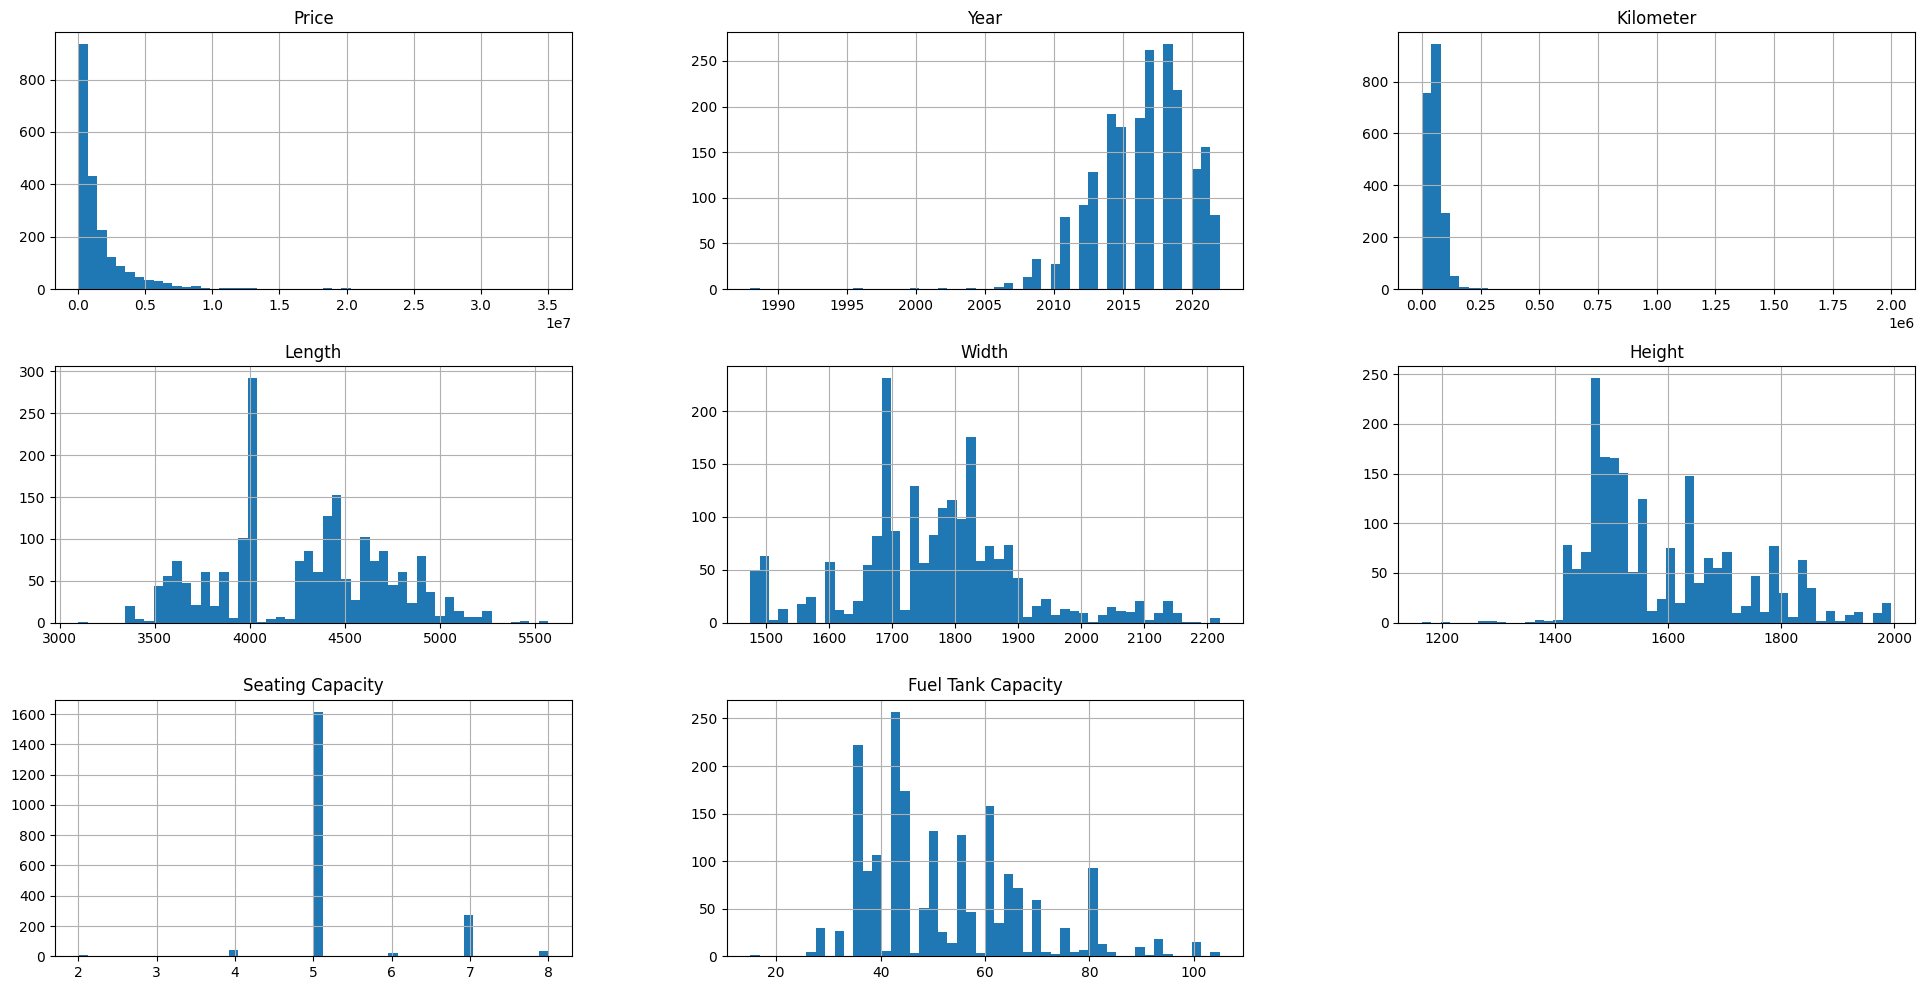

In [50]:
data.hist(bins=50, figsize=(24,12))

In [51]:
corr = data.corr(numeric_only=True)
corr['Price'].sort_values(ascending=False)

,Price
Price,1.000000
Fuel Tank Capacity,0.584631
Width,0.563996
Length,0.556741
Year,0.311400
Height,0.075080
Seating Capacity,-0.038524
Kilometer,-0.150825


array([[<Axes: xlabel='Price', ylabel='Price'>,
        <Axes: xlabel='Fuel Tank Capacity', ylabel='Price'>,
        <Axes: xlabel='Width', ylabel='Price'>,
        <Axes: xlabel='Length', ylabel='Price'>,
        <Axes: xlabel='Year', ylabel='Price'>],
       [<Axes: xlabel='Price', ylabel='Fuel Tank Capacity'>,
        <Axes: xlabel='Fuel Tank Capacity', ylabel='Fuel Tank Capacity'>,
        <Axes: xlabel='Width', ylabel='Fuel Tank Capacity'>,
        <Axes: xlabel='Length', ylabel='Fuel Tank Capacity'>,
        <Axes: xlabel='Year', ylabel='Fuel Tank Capacity'>],
       [<Axes: xlabel='Price', ylabel='Width'>,
        <Axes: xlabel='Fuel Tank Capacity', ylabel='Width'>,
        <Axes: xlabel='Width', ylabel='Width'>,
        <Axes: xlabel='Length', ylabel='Width'>,
        <Axes: xlabel='Year', ylabel='Width'>],
       [<Axes: xlabel='Price', ylabel='Length'>,
        <Axes: xlabel='Fuel Tank Capacity', ylabel='Length'>,
        <Axes: xlabel='Width', ylabel='Length'>,
        <Axes

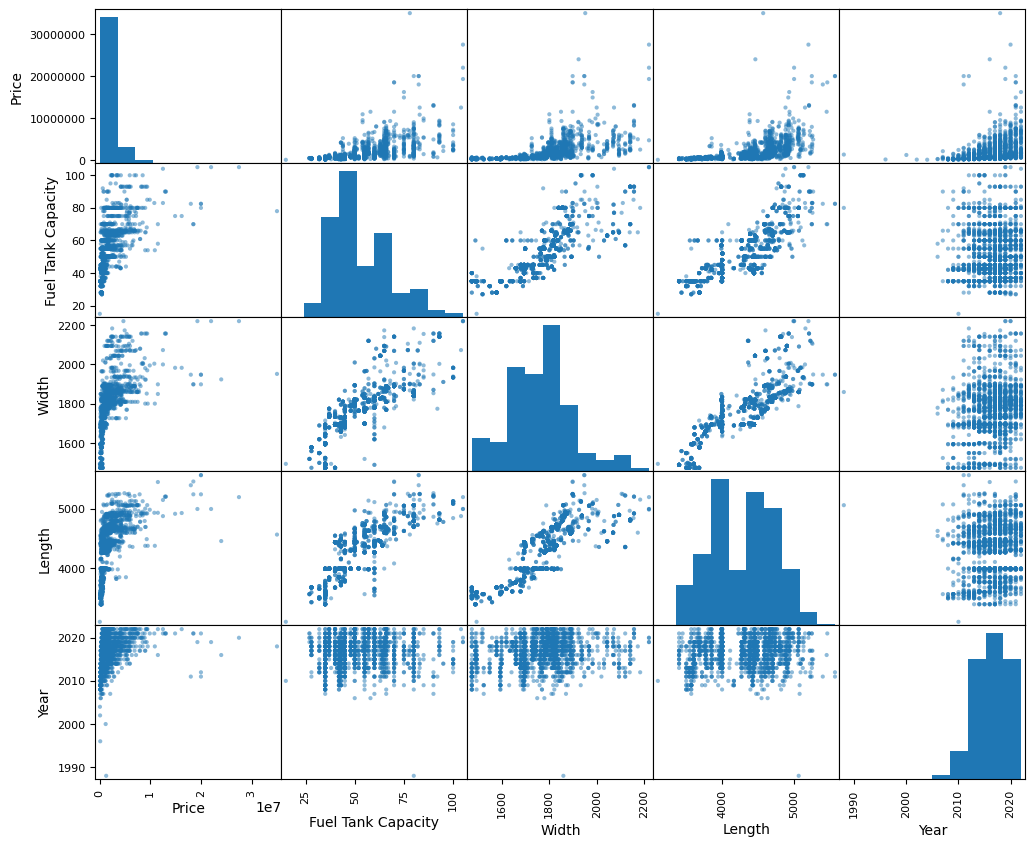

In [52]:
feat =  ['Price', 'Fuel Tank Capacity', 'Width', 'Length', 'Year']
scatter_matrix(data[feat], figsize=(12,10))

In [53]:
data.Price

,Price
0,505000
1,450000
2,220000
3,799000
4,1950000
...,...
2054,850000
2055,275000
2056,240000
2057,4290000


In [62]:
data["Price"] = np.log(data["Price"])
data["Kilometer"] = np.log(data["Kilometer"])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [63]:
data["Price_cat"] = pd.qcut(data['Price'], q=4, labels=[1,2,3,4])
train_set, test_set = train_test_split(data, train_size=0.8, test_size=0.2, random_state=42, stratify=data["Price_cat"])

In [64]:
categorical_cols = train_set.select_dtypes(include='object').columns.tolist()
numerical_cols = train_set.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [65]:
len(data.columns)

21

In [66]:
len(categorical_cols)

12

In [67]:
len(numerical_cols)

8

In [68]:
len(train_set)

1647

In [69]:
for i in [train_set, test_set]:
  i.drop(columns=['Price_cat'], inplace=True)